<a href="https://colab.research.google.com/github/nomanabdullah04/MaChineLearning/blob/main/MultipleLinerRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**In this session we will discuss About Multiple Linear Regression**

---



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

df=pd.read_csv("/content/sample_data/economic_index.csv")
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**In ths data set we used three coloum ,interest_rate	unemployment_rate,	index_price.**

In [9]:
#drop unneccessary columns
df.drop(columns=['year','month','Unnamed: 0'],axis=1,inplace=True, errors='ignore')
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [10]:
#Check Null values
df.isnull().sum()

,0
interest_rate,0
unemployment_rate,0
index_price,0


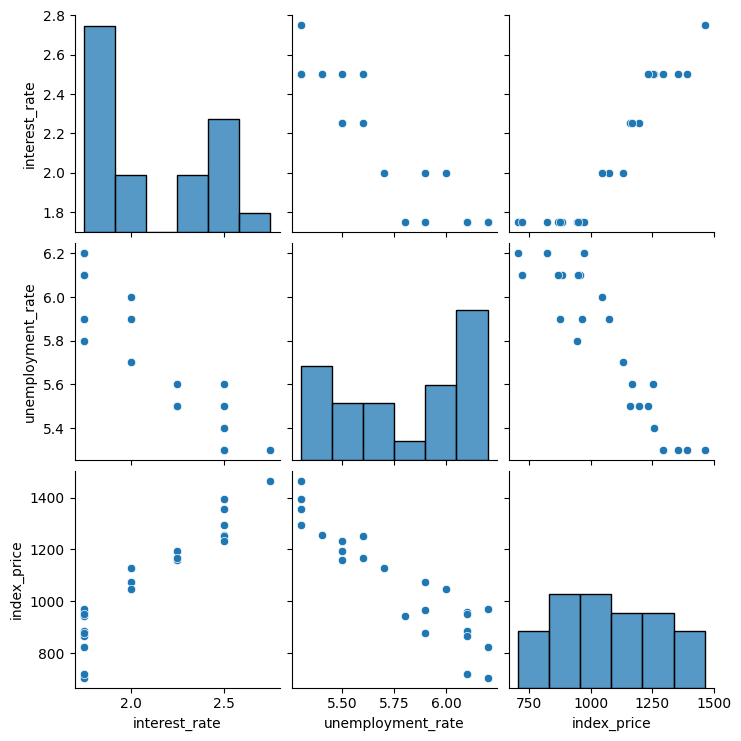

In [11]:
#Lets see the visualization
import seaborn as sns
sns.pairplot(df)


In [12]:
#Check the correlation ech other

df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


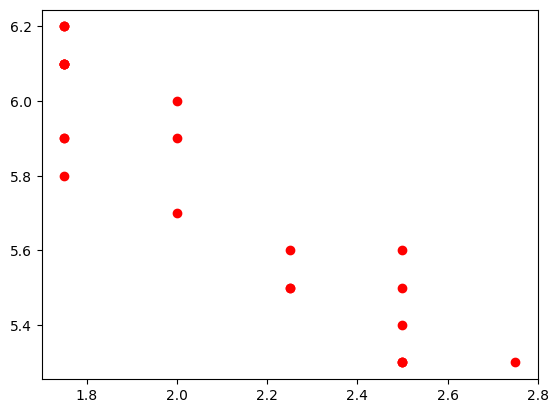

In [16]:
from matplotlib import colors
#Visualiza the datapoint more closely
plt.scatter(df['interest_rate'],df['unemployment_rate'],c='red')
plt.xlabel("Interest Rate")
plt.yblabe("")

Text(0, 0.5, 'Unemployement rate')

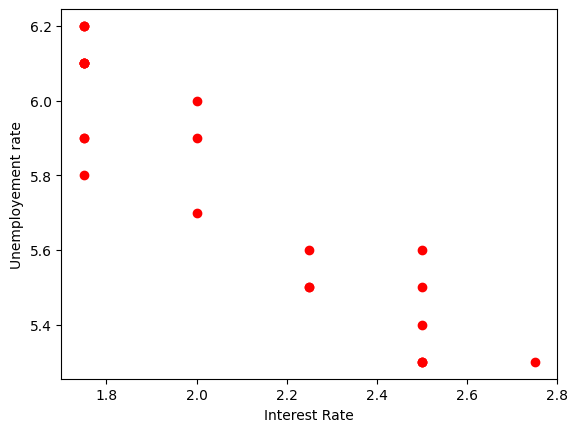

In [19]:
from matplotlib import colors
#Visualiza the datapoint more closely
plt.scatter(df['interest_rate'],df['unemployment_rate'],c='red')
plt.xlabel("Interest Rate")
plt.ylabel("Unemployement rate")

In [23]:
#independent and dependent feature
x=df.iloc[:,:-1]
y=df.iloc[:,-1]
x.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [24]:
y

,index_price
0,1464
1,1394
2,1357
3,1293
4,1256
5,1254
6,1234
7,1195
8,1159
9,1167


In [25]:
#Train test split

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

We use **sns.regplot** from the Seaborn library to plot a scatter plot with a linear regression line automatically drawn through the data points.It is a powerful tool for visual data analysis because it instantly shows you the relationship and trend between two numerical variables.


<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

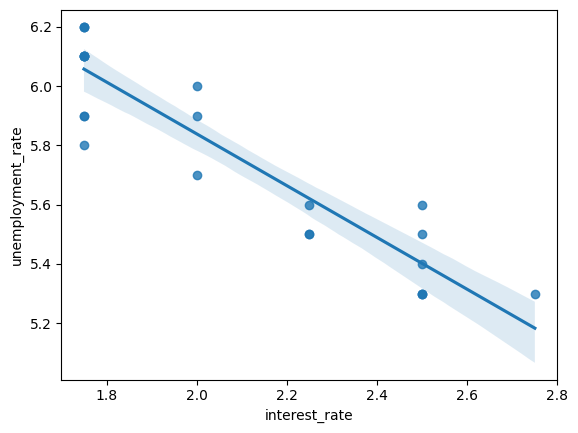

In [27]:
sns.regplot(x='interest_rate', y='unemployment_rate', data=df)

<Axes: xlabel='interest_rate', ylabel='index_price'>

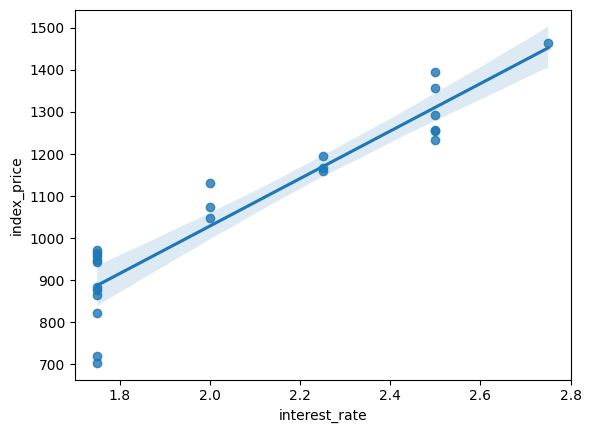

In [28]:
sns.regplot(x='interest_rate',y='index_price',data=df)

<Axes: xlabel='unemployment_rate', ylabel='index_price'>

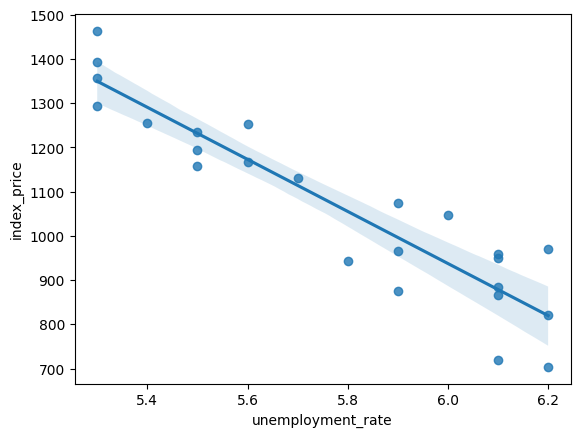

In [29]:
sns.regplot(x='unemployment_rate',y='index_price',data=df)

In [31]:
from sklearn.preprocessing import StandardScaler
score=StandardScaler()
x_train=score.fit_transform(x_train)
x_test=score.transform(x_test)

x_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

***fit():*** The algorithm analyzes the column to calculate the underlying statistics. For example, if you are scaling data using StandardScaler, fit() calculates the mean and standard deviation.

***transform():*** The algorithm uses those exact calculated statistics to mathematically modify the values in your dataset.

***fit_transform():*** Does both. It calculates the mean and standard deviation, and then immediately transforms the numbers.



In [32]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(x_train,y_train)


LinearRegression()

In [34]:
predication=regression.predict(x_test)


,0
0,1204.227704
1,821.650519
2,1406.513004
3,857.708896
4,994.909923
